# Семантический поиск по текстовым документам

**Цель работы:** поулчить модель, которая будет хорошо ранжировать документы на основе запросов пользователей

**Что реализовано:**

1. TF-IDF как простой baseline.
2. Предобученная MiniLM.
3. MiniLM после контрастивного дообучения.
4. Метрики NDCG, Recall, MRR и MAP.
5. Рабочая функция семантического поиска.


In [1]:
# %pip install -q datasets transformers scikit-learn pandas numpy matplotlib tqdm

In [2]:
import math
import random
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from datasets import load_dataset
from IPython.display import display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup

SEED = 17
MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
MAX_LENGTH = 256
TOP_K = 100

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Устройство:", device)


Устройство: mps


## 2. Загрузка и разделение данных


In [3]:
corpus_ds = load_dataset("BeIR/scifact", "corpus", split="corpus")
queries_ds = load_dataset("BeIR/scifact", "queries", split="queries")
train_qrels_ds = load_dataset("BeIR/scifact-qrels", split="train")
test_qrels_ds = load_dataset("BeIR/scifact-qrels", split="test")

corpus_meta = {str(row["_id"]): 
               {"title": (row["title"] or "").strip(),"text": (row["text"] or "").strip(),}
    for row in corpus_ds}
corpus = {doc_id: f"{item['title']}. {item['text']}".strip(". ") for doc_id, item in corpus_meta.items()}
all_queries = {str(row["_id"]): row["text"] for row in queries_ds}

corpus_ids = list(corpus)
corpus_texts = [corpus[doc_id] for doc_id in corpus_ids]

print(f"Документов: {len(corpus)}")
print(f"Запросов: {len(all_queries)}")

Документов: 5183
Запросов: 1109


In [4]:
def make_qrels(dataset):
    qrels = {}
    for row in dataset:
        query_id = str(row["query-id"])
        doc_id = str(row["corpus-id"])
        relevance = float(row["score"])
        if relevance > 0:
            qrels.setdefault(query_id, {})[doc_id] = relevance
    return qrels


full_train_qrels = make_qrels(train_qrels_ds)
test_qrels = make_qrels(test_qrels_ds)

train_ids, val_ids = train_test_split(
    sorted(full_train_qrels),
    test_size=0.15,
    random_state=SEED,)
test_ids = sorted(test_qrels)

train_qrels = {qid: full_train_qrels[qid] for qid in train_ids}
val_qrels = {qid: full_train_qrels[qid] for qid in val_ids}

train_queries = {qid: all_queries[qid] for qid in train_ids}
val_queries = {qid: all_queries[qid] for qid in val_ids}
test_queries = {qid: all_queries[qid] for qid in test_ids}

split_table = pd.DataFrame(
    {
        "Выборка": ["Train", "Validation", "Test"],
        "Запросы": [len(train_ids), len(val_ids), len(test_ids)],
        "Релевантные пары": [
            sum(map(len, train_qrels.values())),
            sum(map(len, val_qrels.values())),
            sum(map(len, test_qrels.values())),],})
display(split_table)


,Выборка,Запросы,Релевантные пары
0,Train,687,779
1,Validation,122,140
2,Test,300,339


## 3. Краткий анализ данных


Медианна длины документ = 204 слов
Пустые документов =  0


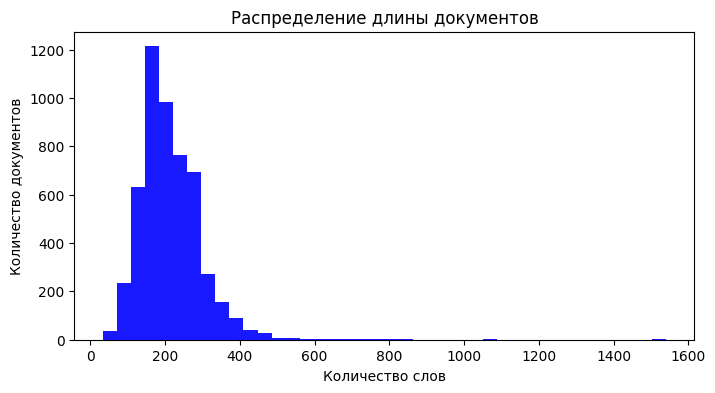

In [5]:
document_lengths = np.array([len(text.split()) for text in corpus_texts])

print("Медианна длины документ =", int(np.median(document_lengths)), "слов")
print("Пустые документов = ", sum(not text.strip() for text in corpus_texts))

plt.figure(figsize=(8, 4))
plt.hist(document_lengths, bins=40, color="blue", alpha=0.9)
plt.title("Распределение длины документов")
plt.xlabel("Количество слов")
plt.ylabel("Количество документов")
plt.show()

## 4. Собственные метрики поиска

- **NDCG@k** оценивает порядок релевантных документов.
- **Recall@k** показывает, какую долю релевантных документов удалось найти.
- **MRR@k** учитывает позицию первого релевантного документа.
- **MAP@k** учитывает точность на всех релевантных позициях.

In [6]:
def ranked_ids(query_results, k):
    return [
        doc_id
        for doc_id, _ in sorted(
            query_results.items(),
            key=lambda item: item[1],
            reverse=True,)[:k]]


def metrics_for_query(true_docs, query_results, k):
    predicted = ranked_ids(query_results, k)
    relevances = np.array([true_docs.get(doc_id, 0) for doc_id in predicted])
    hits = relevances > 0

    discounts = np.log2(np.arange(2, len(relevances) + 2))
    dcg = np.sum((2 ** relevances - 1) / discounts) if len(relevances) else 0

    ideal = np.array(sorted(true_docs.values(), reverse=True)[:k])
    ideal_discounts = np.log2(np.arange(2, len(ideal) + 2))
    idcg = np.sum((2 ** ideal - 1) / ideal_discounts) if len(ideal) else 0
    ndcg = dcg / idcg if idcg else 0.0

    relevant_count = sum(value > 0 for value in true_docs.values())
    recall = hits.sum() / relevant_count if relevant_count else 0

    hit_positions = np.flatnonzero(hits)
    mrr = 1 / (hit_positions[0] + 1) if len(hit_positions) else 0

    if len(hit_positions):
        cumulative_hits = np.cumsum(hits)
        precisions = cumulative_hits[hit_positions] / (hit_positions + 1)
        average_precision = precisions.sum() / min(relevant_count, k)
    else:
        average_precision = 0

    return {
        f"NDCG@{k}": float(ndcg),
        f"Recall@{k}": float(recall),
        f"MRR@{k}": float(mrr),
        f"MAP@{k}": float(average_precision),}


def evaluate(qrels, results):
    final = {}
    for k in (10, 100):
        rows = [
            metrics_for_query(true_docs, results.get(query_id, {}), k)
            for query_id, true_docs in qrels.items()]
        for metric in rows[0]:
            final[metric] = float(np.mean([row[metric] for row in rows]))
    return final


## 5. Вспомогательные функции ранжирования


In [7]:
def top_results(score_matrix, query_ids, top_k=100):
    top_k = min(top_k, len(corpus_ids))
    results = {}

    for row, query_id in enumerate(query_ids):
        scores = score_matrix[row]
        indices = np.argpartition(scores, -top_k)[-top_k:]
        indices = indices[np.argsort(scores[indices])[::-1]]
        results[query_id] = {
            corpus_ids[index]: float(scores[index])
            for index in indices}
    
    
    return results


def dense_results(query_embeddings, corpus_embeddings, query_ids):
    scores = query_embeddings @ corpus_embeddings.T
    return top_results(scores.numpy(), query_ids, TOP_K)


## 6. Baseline TF-IDF


In [8]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=50_000,
    ngram_range=(1, 2),)
corpus_tfidf = vectorizer.fit_transform(corpus_texts)


def run_tfidf(queries, qrels):
    query_ids = sorted(queries)
    query_matrix = vectorizer.transform([queries[qid] for qid in query_ids])
    score_matrix = (query_matrix @ corpus_tfidf.T).toarray()
    results = top_results(score_matrix, query_ids, TOP_K)
    return results, evaluate(qrels, results)


tfidf_test_results, tfidf_metrics = run_tfidf(test_queries, test_qrels)
display(pd.DataFrame([tfidf_metrics], index=["TF-IDF"]).round(4))


,NDCG@10,Recall@10,MRR@10,MAP@10,NDCG@100,Recall@100,MRR@100,MAP@100
TF-IDF,0.5617,0.7087,0.5205,0.5104,0.6,0.8769,0.5279,0.5195


## 7. MiniLM и получение эмбеддингов

MiniLM переводит запросы и документы в векторы размерности 384. После нормализации скалярное произведение векторов соответствует cosine similarity


In [9]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME).to(device)


def mean_pooling(token_embeddings, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand_as(token_embeddings).float()
    return (token_embeddings * mask).sum(1) / mask.sum(1).clamp(min=1e-9)


@torch.inference_mode()
def encode_texts(texts, batch_size=64, show_progress=False):
    model.eval()
    embeddings = []
    iterator = range(0, len(texts), batch_size)
    if show_progress:
        iterator = tqdm(iterator, desc="Кодирование")

    for start in iterator:
        batch = texts[start : start + batch_size]
        encoded = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors="pt",
        ).to(device)
        tokens = model(**encoded).last_hidden_state
        vectors = mean_pooling(tokens, encoded["attention_mask"])
        embeddings.append(F.normalize(vectors, p=2, dim=1).cpu())

    return torch.cat(embeddings)


def run_dense(queries, qrels, corpus_embeddings):
    query_ids = sorted(queries)
    query_embeddings = encode_texts([queries[qid] for qid in query_ids])
    results = dense_results(query_embeddings, corpus_embeddings, query_ids)
    return results, evaluate(qrels, results)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

## 8. Качество MiniLM до дообучения


In [10]:
base_corpus_embeddings = encode_texts(
    corpus_texts,
    batch_size=64,
    show_progress=True,)

base_test_results, base_metrics = run_dense(
    test_queries,
    test_qrels,
    base_corpus_embeddings,)

display(pd.DataFrame([base_metrics], index=["MiniLM до обучения"]).round(4))


Кодирование:   0%|          | 0/81 [00:00<?, ?it/s]

,NDCG@10,Recall@10,MRR@10,MAP@10,NDCG@100,Recall@100,MRR@100,MAP@100
MiniLM до обучения,0.6479,0.79,0.6055,0.598,0.6779,0.9283,0.6111,0.6043


## 9. Подготовка пар для дообучения


In [11]:
train_pairs = [(all_queries[query_id], corpus[doc_id])
    for query_id, documents in train_qrels.items()
    for doc_id, relevance in documents.items()
    if relevance > 0]


class PairDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs
    def __len__(self):
        return len(self.pairs)
    def __getitem__(self, index):
        return self.pairs[index]

train_loader = DataLoader(
    PairDataset(train_pairs),
    batch_size=16,
    shuffle=True,
    generator=torch.Generator().manual_seed(SEED),)

print("Обучающих пар:", len(train_pairs))

Обучающих пар: 779


## 10. Контрастивное дообучение

Внутри батча правильные пары «запрос — документ» находятся на диагонали матрицы сходства. Лучшая эпоха выбирается по NDCG@10 на validation.


In [12]:
EPOCHS = 3
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(total_steps * 0.1),
    num_training_steps=total_steps,)

history = []
best_ndcg = -1.0
best_state = None

for epoch in range(1, EPOCHS + 1):
    model.train()
    losses = []

    for query_batch, document_batch in tqdm(train_loader, desc=f"Эпоха {epoch}"):
        query_inputs = tokenizer(
            list(query_batch),
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors="pt",
        ).to(device)
        document_inputs = tokenizer(
            list(document_batch),
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors="pt",
        ).to(device)

        query_tokens = model(**query_inputs).last_hidden_state
        document_tokens = model(**document_inputs).last_hidden_state

        query_vectors = F.normalize(
            mean_pooling(query_tokens, query_inputs["attention_mask"]),
            p=2,
            dim=1)
        document_vectors = F.normalize(
            mean_pooling(document_tokens, document_inputs["attention_mask"]),
            p=2,
            dim=1)

        logits = query_vectors @ document_vectors.T * 20.0
        labels = torch.arange(len(query_vectors), device=device)
        loss = 0.5 * (F.cross_entropy(logits, labels)+ F.cross_entropy(logits.T, labels))

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        losses.append(loss.item())

    val_corpus_embeddings = encode_texts(corpus_texts, batch_size=64)
    _, val_metrics = run_dense(val_queries, val_qrels, val_corpus_embeddings)

    history.append(
        {
            "Эпоха": epoch,
            "Train loss": np.mean(losses),
            "Validation NDCG@10": val_metrics["NDCG@10"],})

    if val_metrics["NDCG@10"] > best_ndcg:
        best_ndcg = val_metrics["NDCG@10"]
        best_state = {
            name: tensor.detach().cpu().clone()
            for name, tensor in model.state_dict().items()}

    print(history[-1])

model.load_state_dict(best_state)
model = model.to(device)
print(f"Лучший validation NDCG@10: {best_ndcg:.4f}")

Эпоха 1:   0%|          | 0/49 [00:00<?, ?it/s]

{'Эпоха': 1, 'Train loss': np.float64(0.21192666329443455), 'Validation NDCG@10': 0.684583808437023}


Эпоха 2:   0%|          | 0/49 [00:00<?, ?it/s]

{'Эпоха': 2, 'Train loss': np.float64(0.11528440530658984), 'Validation NDCG@10': 0.6844774018535763}


Эпоха 3:   0%|          | 0/49 [00:00<?, ?it/s]

{'Эпоха': 3, 'Train loss': np.float64(0.06541880287172995), 'Validation NDCG@10': 0.6870127556212509}
Лучший validation NDCG@10: 0.6870


## 11. Результаты обучения


,Эпоха,Train loss,Validation NDCG@10
0,1,0.2119,0.6846
1,2,0.1153,0.6845
2,3,0.0654,0.6870


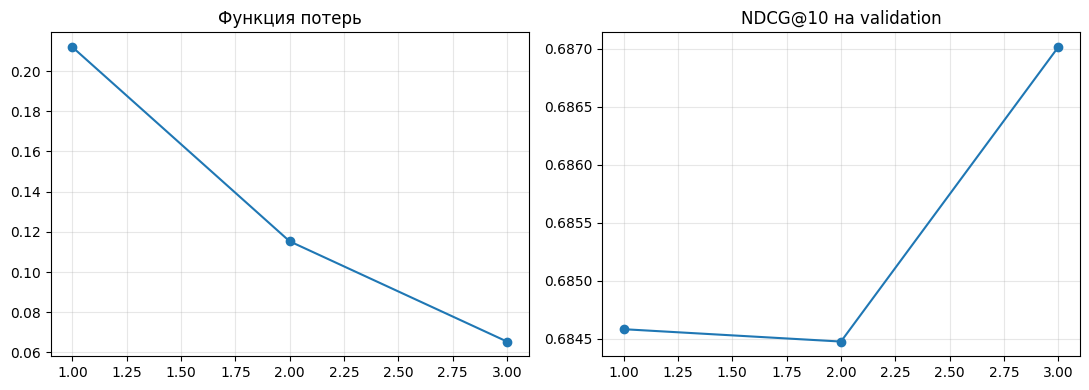

In [13]:
history_df = pd.DataFrame(history)
display(history_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history_df["Эпоха"], history_df["Train loss"], marker="o")
axes[0].set_title("Функция потерь")
axes[0].grid(alpha=0.3)

axes[1].plot(
    history_df["Эпоха"],
    history_df["Validation NDCG@10"],
    marker="o",)
axes[1].set_title("NDCG@10 на validation")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 11. BGE-M3 на англоязычном корпусе

Для дополнительного сравнения применим BGE-M3 к тому же корпусу SciFact и к той же test-выборке, что использовались для TF-IDF и MiniLM. Это позволяет сравнивать модели в одинаковых условиях.

In [10]:
from pathlib import Path

current_dir = Path.cwd()

print("Jupyter работает из папки:")
print(current_dir)

model_configs = list(
    current_dir.rglob("BAAI--bge-m3/snapshots/*/config.json")
)

if not model_configs:
    raise FileNotFoundError(
        "BGE-M3 не найдена внутри текущей папки Jupyter"
    )

BGE_MODEL_DIR = model_configs[0].parent

print("Найдена модель:")
print(BGE_MODEL_DIR)

Jupyter работает из папки:
/Users/dud0k3
Найдена модель:
/Users/dud0k3/models/models/BAAI--bge-m3/snapshots/master


In [11]:
from FlagEmbedding import BGEM3FlagModel

bge_model = BGEM3FlagModel(
    str(BGE_MODEL_DIR),
    use_fp16=False)

print("BGE-M3 загружена локально")

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BGE-M3 загружена локально


In [31]:
@torch.inference_mode()
def encode_bge(texts, batch_size=8, max_length=512, show_progress=False):
    """Получение нормализованных dense-векторов BGE-M3."""
    iterator = range(0, len(texts), batch_size)
    if show_progress:
        iterator = tqdm(iterator, desc="Кодирование BGE-M3")

    vectors = []
    for start in iterator:
        batch = texts[start : start + batch_size]
        encoded = bge_model.encode(
            batch,
            batch_size=batch_size,
            max_length=max_length)
        dense_vecs = torch.as_tensor(encoded["dense_vecs"], dtype=torch.float32)
        vectors.append(F.normalize(dense_vecs, p=2, dim=1).cpu())
    return torch.cat(vectors)


def run_bge(queries, qrels, corpus_embeddings):
    query_ids = sorted(queries)
    query_embeddings = encode_bge(
        [queries[qid] for qid in query_ids],
        batch_size=8,)
    results = dense_results(query_embeddings, corpus_embeddings, query_ids)
    return results, evaluate(qrels, results)

bge_corpus_embeddings = encode_bge(
    corpus_texts,
    batch_size=8,
    show_progress=True)
bge_test_results, bge_metrics = run_bge(
    test_queries,
    test_qrels,
    bge_corpus_embeddings)

display(pd.DataFrame([bge_metrics], index=["BGE-M3"]).round(4))

Кодирование BGE-M3:   0%|          | 0/648 [00:00<?, ?it/s]


pre tokenize: 100%|███████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 27.40it/s]

Inference Embeddings: 100%|███████████████████████████████████████████████████████████████| 1/1 [00:02<00:00,  2.11s/it]

pre tokenize: 100%|██████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 392.28it/s]

Inference Embeddings: 100%|███████████████████████████████████████████████████████████████| 1/1 [00:02<00:00,  2.21s/it]

pre tokenize: 100%|██████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 552.25it/s]

Inference Embeddings: 100%|███████████████████████████████████████████████████████████████| 1/1 [00:02<00:00,  2.19s/it]

pre tokenize: 100%|██████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 473.93it/s]

Inference Embeddings: 100%|███████████████████████████████████████████████████████████████| 1/1 [00:02<00:00,  2.21s/it]

pre tokenize: 100%|████

,NDCG@10,Recall@10,MRR@10,MAP@10,NDCG@100,Recall@100,MRR@100,MAP@100
BGE-M3,0.6519,0.7851,0.6188,0.6028,0.6788,0.907,0.623,0.609


In [32]:
tuned_corpus_embeddings = encode_texts(
    corpus_texts,
    batch_size=64,
    show_progress=True)
tuned_test_results, tuned_metrics = run_dense(
    test_queries,
    test_qrels,
    tuned_corpus_embeddings,)

comparison = pd.DataFrame(
    [
        {"Модель": "TF-IDF", **tfidf_metrics},
        {"Модель": "MiniLM до обучения", **base_metrics},
        {"Модель": "MiniLM после обучения", **tuned_metrics},
        {"Модель": "BGE-M3", **bge_metrics}]).set_index("Модель")

columns = ["NDCG@10", "Recall@10", "MRR@10", "MAP@100"]
display(comparison[columns].round(4))

improvement = tuned_metrics["NDCG@10"] - tfidf_metrics["NDCG@10"]
print(f"Прирост NDCG@10 относительно TF-IDF: {improvement:+.4f}")

Кодирование:   0%|          | 0/81 [00:00<?, ?it/s]

,NDCG@10,Recall@10,MRR@10,MAP@100
Модель,,,,
TF-IDF,0.5617,0.7087,0.5205,0.5195
MiniLM до обучения,0.6479,0.7900,0.6055,0.6043
MiniLM после обучения,0.6899,0.8428,0.6457,0.6429
BGE-M3,0.6519,0.7851,0.6188,0.6090


Прирост NDCG@10 относительно TF-IDF: +0.1283


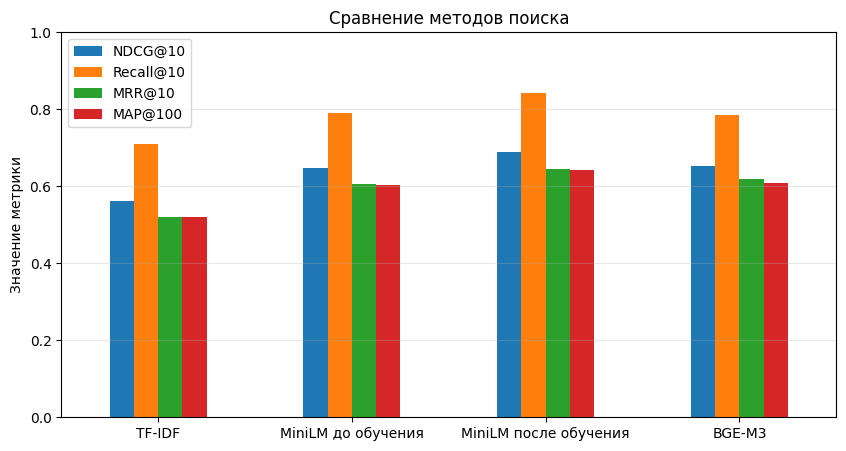

In [33]:
comparison[["NDCG@10", "Recall@10", "MRR@10", "MAP@100"]].plot(
    kind="bar",
    figsize=(10, 5),
    rot=0,
    ylim=(0, 1)к)
plt.title("Сравнение методов поиска")
plt.ylabel("Значение метрики")
plt.xlabel("")
plt.grid(axis="y", alpha=0.3)
plt.show()

## 12. Пример ошибки и улучшения


In [34]:
rows = []
for query_id in test_ids:
    tfidf_ndcg = metrics_for_query(
        test_qrels[query_id],
        tfidf_test_results[query_id],
        10,
    )["NDCG@10"]
    tuned_ndcg = metrics_for_query(
        test_qrels[query_id],
        tuned_test_results[query_id],
        10,
    )["NDCG@10"]
    rows.append(
        {
            "query_id": query_id,
            "Запрос": test_queries[query_id],
            "TF-IDF": tfidf_ndcg,
            "MiniLM": tuned_ndcg,
            "Разница": tuned_ndcg - tfidf_ndcg,})

analysis = pd.DataFrame(rows)
print("Где MiniLM лучше:")
display(analysis.nlargest(3, "Разница").round(4))
print("Где TF-IDF лучше:")
display(analysis.nsmallest(3, "Разница").round(4))

Где MiniLM лучше:


,query_id,Запрос,TF-IDF,MiniLM,Разница
13,1088,Silencing of Bcl2 is important for the mainten...,0.0,1.0,1.0
24,1137,TNFAIP3 is a tumor suppressor in glioblastoma.,0.0,1.0,1.0
49,1225,The locus rs647161 is associated with colorect...,0.0,1.0,1.0


Где TF-IDF лучше:


,query_id,Запрос,TF-IDF,MiniLM,Разница
215,623,Individuals with low serum vitamin D concentra...,1.0000,0.0000,-1.0000
167,452,Gene expression does not vary appreciably acro...,0.8772,0.0000,-0.8772
186,527,Homozygous deletion of murine Sbds gene from o...,1.0000,0.3333,-0.6667


## 13. Поиск top-10 документов по произвольному запросу

Функция использует **дообученную MiniLM** и возвращает десять документов с наибольшим cosine similarity. Значение `Score` — не вероятность, а степень семантической близости запроса и документа: чем оно выше, тем документ ближе к запросу по мнению модели.


In [35]:
def semantic_search(query, top_k=10):
    if not isinstance(query, str) or not query.strip():
        raise ValueError("Запрос должен быть непустой строкой.")
    if not 1 <= top_k <= len(corpus_ids):
        raise ValueError(f"top_k должен быть от 1 до {len(corpus_ids)}.")

    query_embedding = encode_texts([query.strip()], batch_size=1)
    scores = (query_embedding @ tuned_corpus_embeddings.T)[0]
    top_scores, top_indices = torch.topk(scores, k=top_k)

    return pd.DataFrame(
        [
            {
                "Позиция": rank,
                "Score (cosine similarity)": round(float(score), 4),
                "ID документа": corpus_ids[index],
                "Заголовок": corpus_meta[corpus_ids[index]]["title"],
                "Фрагмент": corpus_meta[corpus_ids[index]]["text"][:350],}
            for rank, (score, index) in enumerate(
                zip(top_scores.tolist(), top_indices.tolist()), start=1)])


def search_top10(query):
    return semantic_search(query, top_k=10)


my_query = "0-dimensional biomaterials show."
top10_documents = search_top10(my_query)
display(top10_documents)

def semantic_search_bge(query, top_k=10):
    """Поиск top-k документов с использованием локальной BGE-M3."""
    if not isinstance(query, str) or not query.strip():
        raise ValueError("Запрос должен быть непустой строкой.")
    if not 1 <= top_k <= len(corpus_ids):
        raise ValueError(f"top_k должен быть от 1 до {len(corpus_ids)}.")

    query_embedding = encode_bge([query.strip()], batch_size=1)
    scores = (query_embedding @ bge_corpus_embeddings.T)[0]
    top_scores, top_indices = torch.topk(scores, k=top_k)

    return pd.DataFrame(
        [
            {
                "Позиция": rank,
                "Score (cosine similarity)": round(float(score), 4),
                "ID документа": corpus_ids[index],
                "Заголовок": corpus_meta[corpus_ids[index]]["title"],
                "Фрагмент": corpus_meta[corpus_ids[index]]["text"][:350]}
            for rank, (score, index) in enumerate(
                zip(top_scores.tolist(), top_indices.tolist()), start=1)])

# Пример той же выдачи для BGE-M3.
bge_top10_documents = semantic_search_bge(my_query, top_k=10)
display(bge_top10_documents)


,Позиция,Score (cosine similarity),ID документа,Заголовок,Фрагмент
0,1,0.3993,4346436,Nonlinear Elasticity in Biological Gels,"Unlike most synthetic materials, biological ma..."
1,2,0.3804,29638116,Complex Tissue and Disease Modeling using hiPSCs.,Defined genetic models based on human pluripot...
2,3,0.3705,17388232,Mechanical regulation of cell function with ge...,We report the establishment of a library of mi...
3,4,0.3408,31715818,New opportunities: the use of nanotechnologies...,Nanotechnologies are emerging platforms that c...
4,5,0.3354,927561,Emergent structures and dynamics of cell colon...,Cells in tissues can organize into a broad spe...
5,6,0.3214,6863070,Three-dimensional superresolution colocalizati...,"Recently, single-molecule imaging and photocon..."
6,7,0.3152,3874000,Tissue Mechanics Orchestrate Wnt-Dependent Hum...,Regenerative medicine is predicated on underst...
7,8,0.3055,25985964,Very small embryonic-like stem cells with maxi...,Very small embryonic-like stem cells (VSELs) a...
8,9,0.3046,1922901,Forces in Tissue Morphogenesis and Patterning,"During development, mechanical forces cause ch..."
9,10,0.2989,25404036,Three-Dimensional Modeling and Quantitative An...,Gap junctions play a fundamental role in inter...


Inference Embeddings: 100%|███████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 13.22it/s]


,Позиция,Score (cosine similarity),ID документа,Заголовок,Фрагмент
0,1,0.5122,20101846,Homogeneously dispersed multimetal oxygen-evol...,Earth-abundant first-row (3d) transition metal...
1,2,0.5072,3419802,Microenvironment-dependent growth of pre-neopl...,"Most human cancers, including myeloma, are pre..."
2,3,0.5046,16736872,Noninvasive Imaging beyond the Diffraction Lim...,Optical imaging of the dynamics of living spec...
3,4,0.5044,82665667,Detection of [Ca2+]I Changes In Sub-Plasma Mem...,"An optical fiber-based nanobiosensor, for adva..."
4,5,0.5031,4346436,Nonlinear Elasticity in Biological Gels,"Unlike most synthetic materials, biological ma..."
5,6,0.5027,24466904,Successful establishment of long-term bone mar...,We used bone marrow biopsies instead of mononu...
6,7,0.5020,23763738,New colorimetric cytotoxicity assay for antica...,"We have developed a rapid, sensitive, and inex..."
7,8,0.4969,20279166,Label-free DNA imaging in vivo with stimulated...,Label-free DNA imaging is highly desirable in ...
8,9,0.4950,3743071,GSDS 2.0: an upgraded gene feature visualizati...,UNLABELLED : Visualizing genes' structure and ...
9,10,0.4948,9599194,A versatile zero background T-vector system fo...,With the recent availability of complete genom...


## 14. Сохранение модели


In [36]:
output_dir = Path("artifacts/semantic_search")
output_dir.mkdir(parents=True, exist_ok=True)

model.save_pretrained(output_dir / "model")
tokenizer.save_pretrained(output_dir / "model")
torch.save(
    {
        "corpus_ids": corpus_ids,
        "embeddings": tuned_corpus_embeddings,
        "bge_embeddings": bge_corpus_embeddings,

        "metadata": corpus_meta,},
    output_dir / "index.pt",)
comparison.to_csv(output_dir / "metrics.csv", encoding="utf-8")

print("Модель и индекс сохранены в", output_dir)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Модель и индекс сохранены в artifacts/semantic_search
